# Scenario analysis

Reruns Model B (`src/optimization/model_b.py`, same MILP as notebook 06) under demand,
machine, and material shocks, and compares each scenario against the base case. The model
itself does not change here, only its inputs do.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from src.optimization.model_b import load_base_parameters, solve_model_b, extract_results

## Base case

In [2]:
base_params = load_base_parameters()
base_model, base_vars = solve_model_b(base_params)
base_results = extract_results(base_model, base_vars, base_params)

print("base total cost:", round(base_results["total_cost"], 2))
print("base shortage rows:", len(base_results["shortage"]))

Restricted license - for non-production use only - expires 2027-11-29
base total cost: 84286.66
base shortage rows: 13


## Scenario 1: demand increase

Scale the forecast up by 10%, 20%, 30%, same factory, same costs.

In [3]:
def scale_demand(params, factor):
    new_params = dict(params)
    new_params["demand"] = {k: v * factor for k, v in params["demand"].items()}
    return new_params

In [4]:
demand_scenarios = {}
for pct in [10, 20, 30]:
    p2 = scale_demand(base_params, 1 + pct / 100)
    m2, v2 = solve_model_b(p2)
    demand_scenarios[f"demand +{pct}%"] = extract_results(m2, v2, p2)

print("solved:", list(demand_scenarios.keys()))

solved: ['demand +10%', 'demand +20%', 'demand +30%']


## Scenario 2: machine failure

M01 (the busiest machine) goes fully offline for two weeks, a real breakdown, not a
capacity trim.

In [5]:
def fail_machine(params, machine_id, weeks, factor=0.0):
    new_params = dict(params)
    new_hours = dict(params["available_hours"])
    for t in weeks:
        new_hours[(machine_id, t)] *= factor
    new_params["available_hours"] = new_hours
    return new_params

In [6]:
failure_params = fail_machine(base_params, "M01", weeks=[6, 7])
failure_model, failure_vars = solve_model_b(failure_params)
failure_results = extract_results(failure_model, failure_vars, failure_params)

print("machine failure total cost:", round(failure_results["total_cost"], 2))
print("machine failure shortage rows:", len(failure_results["shortage"]))

machine failure total cost: 84558.96
machine failure shortage rows: 14


In [7]:
# shortage during the outage weeks specifically
failure_results["shortage"][failure_results["shortage"]["t"].isin([6, 7])]

,product_id,t,shortage
90,P08,7,417.6


## Scenario 3: material shortage

Cut two different shared materials by the same 50% to compare their impact: `SHR01`
(HOUSEHOLD + HOBBIES, 6 products) vs `SHR02` (only P01 and P02, the two highest-value
products).

In [8]:
def cut_material(params, material_id, factor):
    new_params = dict(params)
    new_avail = dict(params["material_availability"])
    new_avail[material_id] *= factor
    new_params["material_availability"] = new_avail
    return new_params

In [9]:
material_scenarios = {}
for material_id in ["SHR01", "SHR02"]:
    p2 = cut_material(base_params, material_id, factor=0.5)
    m2, v2 = solve_model_b(p2)
    material_scenarios[f"{material_id} -50%"] = extract_results(m2, v2, p2)

print("solved:", list(material_scenarios.keys()))

solved: ['SHR01 -50%', 'SHR02 -50%']


In [10]:
# same 50% cut, very different impact: SHR02 feeds the highest-value product (P01)
for name, r in material_scenarios.items():
    print(name, "cost:", round(r["total_cost"], 2), "shortage rows:", len(r["shortage"]))

SHR01 -50% cost: 84473.81 shortage rows: 25
SHR02 -50% cost: 100288.21 shortage rows: 34


## Compare all scenarios

In [11]:
all_scenarios = {"base": base_results, **demand_scenarios, "machine failure": failure_results, **material_scenarios}

summary = pd.DataFrame({
    name: {
        "total_cost": r["total_cost"],
        "shortage_dollars": r["cost_breakdown"]["cost"].get("shortage", 0),
        "shortage_rows": len(r["shortage"]),
    }
    for name, r in all_scenarios.items()
}).T
summary.round(2)

,total_cost,shortage_dollars,shortage_rows
base,84286.66,1218.10,13.0
demand +10%,93389.36,3508.45,49.0
demand +20%,102710.18,7325.71,56.0
demand +30%,115566.47,18124.30,87.0
machine failure,84558.96,1480.34,14.0
SHR01 -50%,84473.81,4416.70,25.0
SHR02 -50%,100288.21,34942.29,34.0


In [12]:
RESULTS_DIR = Path("../results/tables")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(RESULTS_DIR / "scenario_summary.csv")
print("Saved scenario summary to", RESULTS_DIR.resolve())

Saved scenario summary to C:\Users\HP\Walid\Industrial_production_optimization\results\tables


## Visualization: total cost by scenario

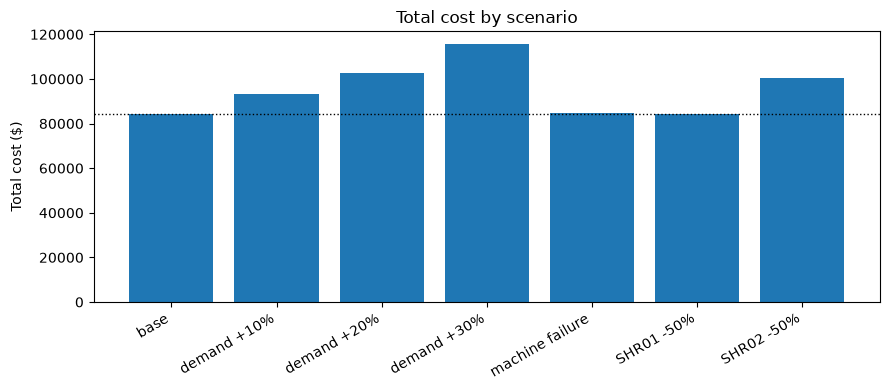

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary.index, summary["total_cost"], color="tab:blue")
ax.axhline(base_results["total_cost"], color="black", linestyle=":", linewidth=1)
ax.set_ylabel("Total cost ($)")
ax.set_title("Total cost by scenario")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Visualization: shortage cost by scenario

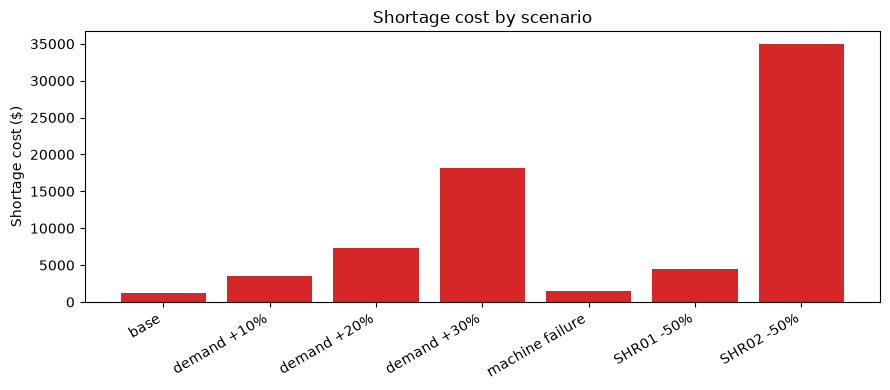

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(summary.index, summary["shortage_dollars"], color="tab:red")
ax.set_ylabel("Shortage cost ($)")
ax.set_title("Shortage cost by scenario")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()